# 📊 Notebook 1: Exploratory Data Analysis

This notebook explores the two datasets:
- `ratings.csv` — user-course interactions with ratings
- `course_genre.csv` — course metadata with genre/tag labels

In [1]:
from pathlib import Path

# ── Paths ───────────────────────────────────────────
DATA_DIR    = Path('data/raw')
FIGURES_DIR = Path('figures/eda')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
PALETTE = 'viridis'


## 1. Load Data

In [2]:
ratings    = pd.read_csv(DATA_DIR / 'ratings.csv')
courses    = pd.read_csv(DATA_DIR / 'course_genre.csv')

print("Ratings shape :", ratings.shape)
print("Courses shape :", courses.shape)
ratings.head()


Ratings shape : (233306, 3)
Courses shape : (307, 16)


,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


In [3]:
courses.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


## 2. Ratings Dataset – Basic Statistics

In [4]:
print("=== ratings.csv ===")
print(ratings.dtypes)
print("\nMissing values:")
print(ratings.isnull().sum())
print("\nRating stats:")
ratings['rating'].describe()


=== ratings.csv ===
user        int64
item       object
rating    float64
dtype: object

Missing values:
user      0
item      0
rating    0
dtype: int64

Rating stats:


count    233306.000000
mean          2.952954
std           0.211737
min           2.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           3.000000
Name: rating, dtype: float64

In [5]:
# Unique counts
print(f"Unique users   : {ratings['user'].nunique():,}")
print(f"Unique courses : {ratings['item'].nunique():,}")
print(f"Total ratings  : {len(ratings):,}")
sparsity = 1 - len(ratings) / (ratings['user'].nunique() * ratings['item'].nunique())
print(f"Matrix sparsity: {sparsity:.4%}")


Unique users   : 33,901
Unique courses : 126
Total ratings  : 233,306
Matrix sparsity: 94.5381%


## 3. Rating Distribution

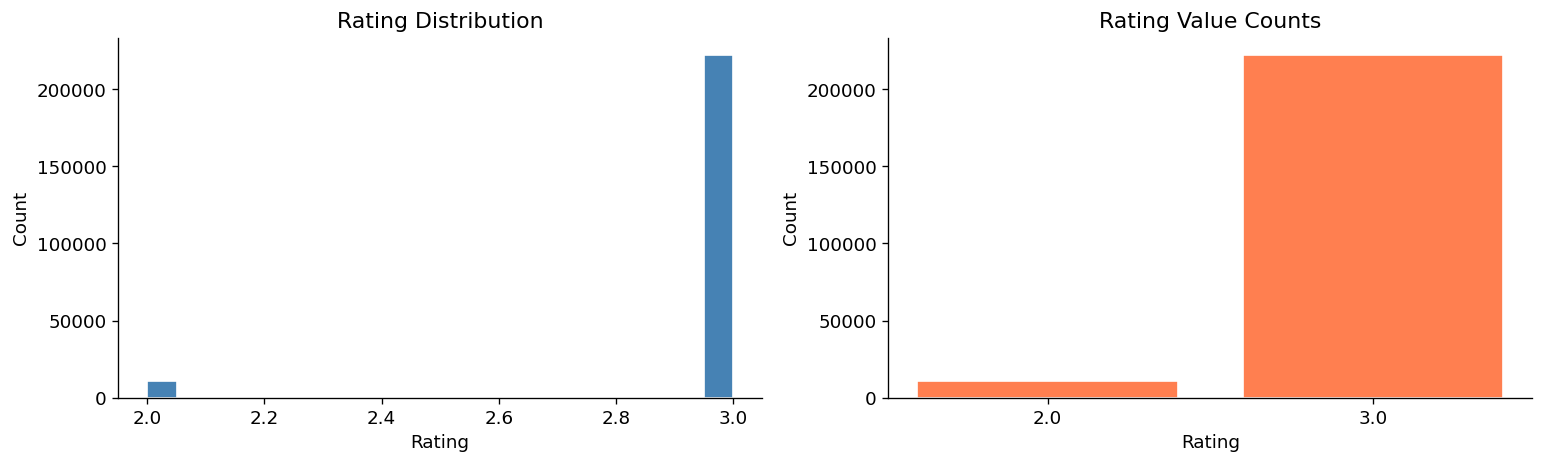

rating
2.0     10976
3.0    222330
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(ratings['rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

# Value counts bar
vc = ratings['rating'].value_counts().sort_index()
axes[1].bar(vc.index.astype(str), vc.values, color='coral', edgecolor='white')
axes[1].set_title('Rating Value Counts')
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(vc)


## 4. User Activity Analysis

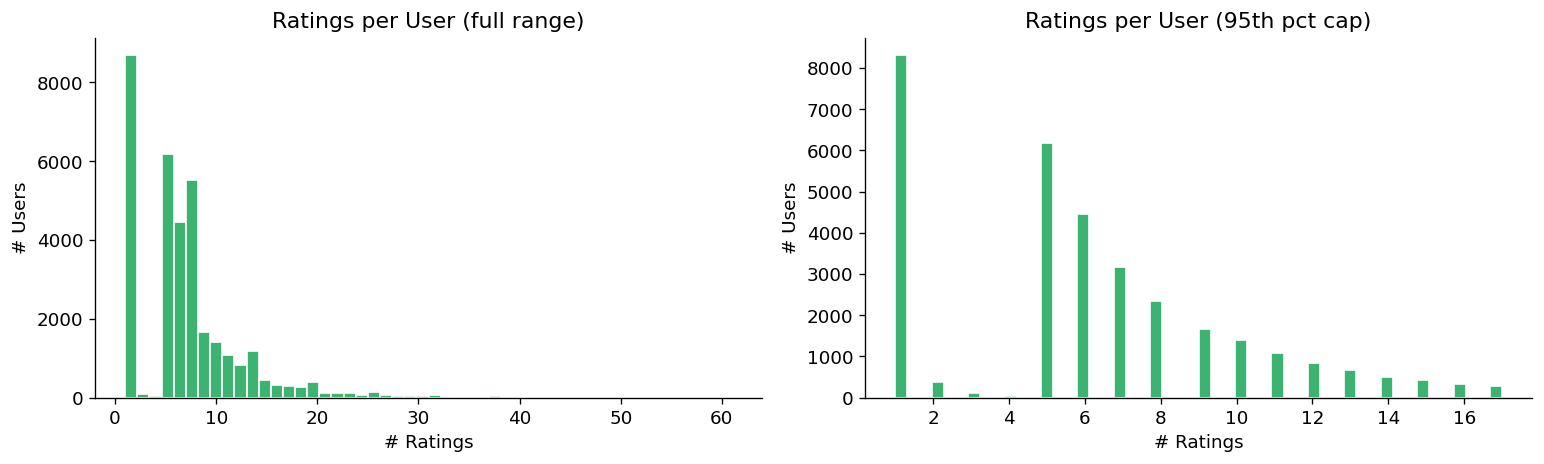

count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
Name: item, dtype: float64


In [7]:
user_counts = ratings.groupby('user')['item'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_counts, bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Ratings per User (full range)')
axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Users')

axes[1].hist(user_counts[user_counts <= user_counts.quantile(0.95)], bins=50,
             color='mediumseagreen', edgecolor='white')
axes[1].set_title('Ratings per User (95th pct cap)')
axes[1].set_xlabel('# Ratings'); axes[1].set_ylabel('# Users')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_user_activity.png', bbox_inches='tight', dpi=150)
plt.show()
print(user_counts.describe())


## 5. Course Popularity

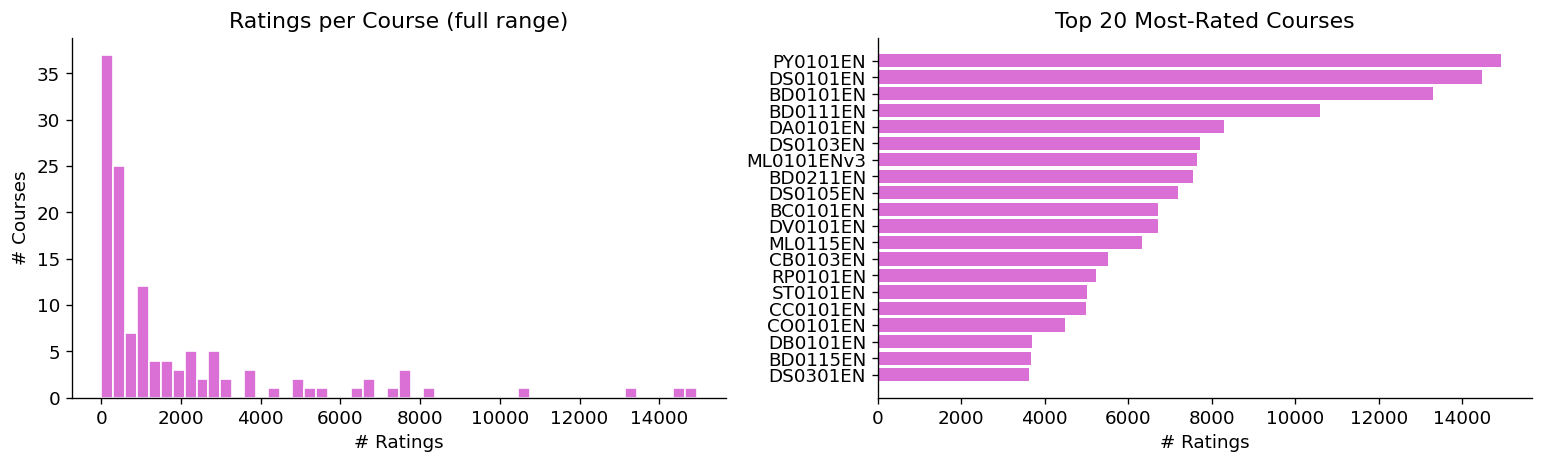

In [8]:
course_counts = ratings.groupby('item')['user'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(course_counts, bins=50, color='orchid', edgecolor='white')
axes[0].set_title('Ratings per Course (full range)')
axes[0].set_xlabel('# Ratings'); axes[0].set_ylabel('# Courses')

top20 = course_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='orchid')
axes[1].set_title('Top 20 Most-Rated Courses')
axes[1].set_xlabel('# Ratings')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_course_popularity.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Average Rating per Course (Top 20)

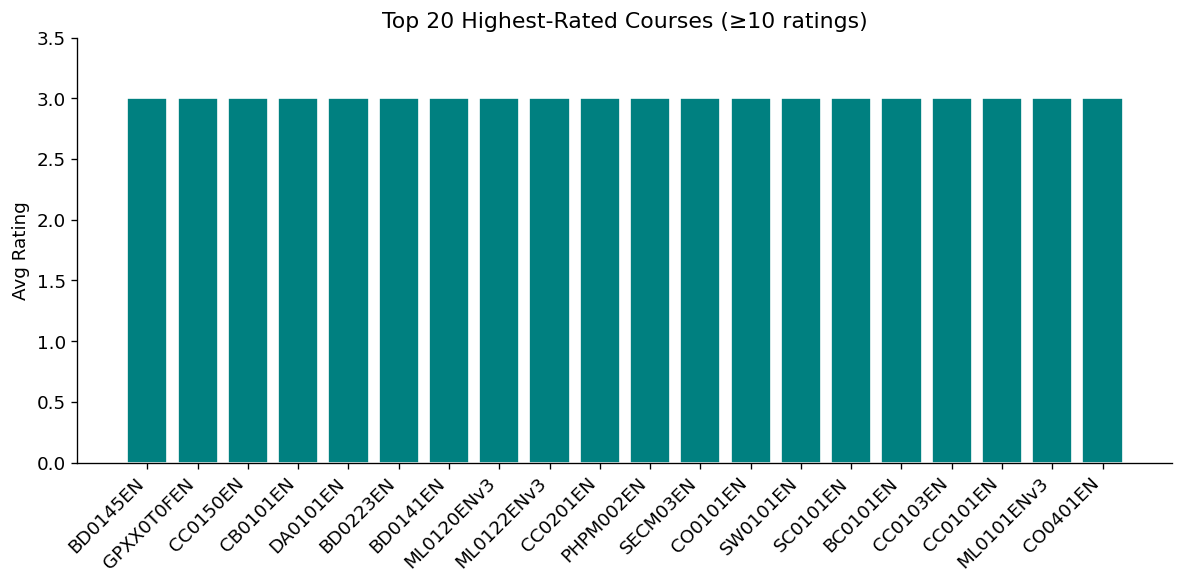

In [9]:
avg_rating = ratings.groupby('item')['rating'].mean().sort_values(ascending=False)
top20_avg = avg_rating[course_counts[avg_rating.index] >= 10].head(20)  # at least 10 ratings

plt.figure(figsize=(10, 5))
plt.bar(range(len(top20_avg)), top20_avg.values, color='teal', edgecolor='white')
plt.xticks(range(len(top20_avg)), top20_avg.index, rotation=45, ha='right')
plt.title('Top 20 Highest-Rated Courses (≥10 ratings)')
plt.ylabel('Avg Rating'); plt.ylim(0, 3.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_avg_rating_top20.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Course Genre / Metadata Analysis

In [10]:
print("=== course_genre.csv ===")
print(courses.dtypes)
print("\nMissing values:")
print(courses.isnull().sum())
courses.describe()


=== course_genre.csv ===
COURSE_ID          object
TITLE              object
Database            int64
Python              int64
CloudComputing      int64
DataAnalysis        int64
Containers          int64
MachineLearning     int64
ComputerVision      int64
DataScience         int64
BigData             int64
Chatbot             int64
R                   int64
BackendDev          int64
FrontendDev         int64
Blockchain          int64
dtype: object

Missing values:
COURSE_ID          0
TITLE              0
Database           0
Python             0
CloudComputing     0
DataAnalysis       0
Containers         0
MachineLearning    0
ComputerVision     0
DataScience        0
BigData            0
Chatbot            0
R                  0
BackendDev         0
FrontendDev        0
Blockchain         0
dtype: int64


,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000
mean,0.195440,0.091205,0.120521,0.182410,0.055375,0.224756,0.032573,0.123779,0.117264,0.013029,0.055375,0.254072,0.061889,0.013029
std,0.397186,0.288371,0.326102,0.386813,0.229083,0.418103,0.177807,0.329866,0.322260,0.113585,0.229083,0.436049,0.241348,0.113585
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


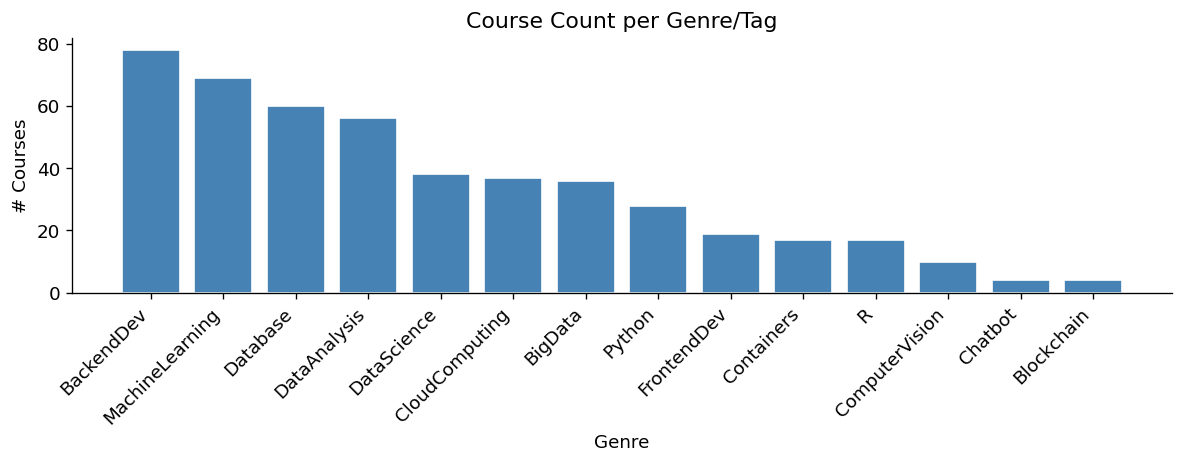

BackendDev         78
MachineLearning    69
Database           60
DataAnalysis       56
DataScience        38
CloudComputing     37
BigData            36
Python             28
FrontendDev        19
Containers         17
R                  17
ComputerVision     10
Chatbot             4
Blockchain          4
dtype: int64


In [11]:
genre_cols = courses.columns[2:].tolist()   # skip COURSE_ID and TITLE
genre_sums = courses[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(genre_sums.index, genre_sums.values, color='steelblue', edgecolor='white')
plt.title('Course Count per Genre/Tag')
plt.xlabel('Genre'); plt.ylabel('# Courses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_genre_counts.png', bbox_inches='tight', dpi=150)
plt.show()
print(genre_sums)


## 8. Multi-Genre Distribution

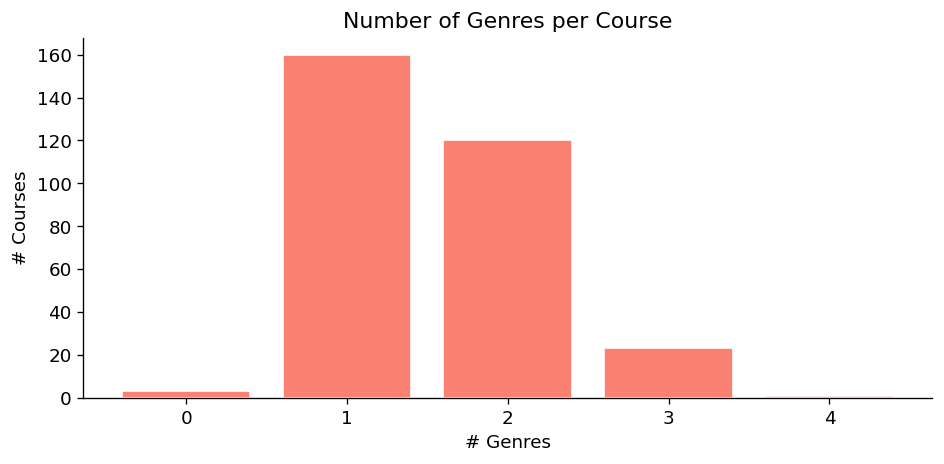

num_genres
0      3
1    160
2    120
3     23
4      1
Name: count, dtype: int64


In [12]:
courses['num_genres'] = courses[genre_cols].sum(axis=1)

plt.figure(figsize=(8, 4))
vc2 = courses['num_genres'].value_counts().sort_index()
plt.bar(vc2.index.astype(str), vc2.values, color='salmon', edgecolor='white')
plt.title('Number of Genres per Course')
plt.xlabel('# Genres'); plt.ylabel('# Courses')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_multi_genre_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(vc2)


## 9. Genre Co-occurrence Heatmap

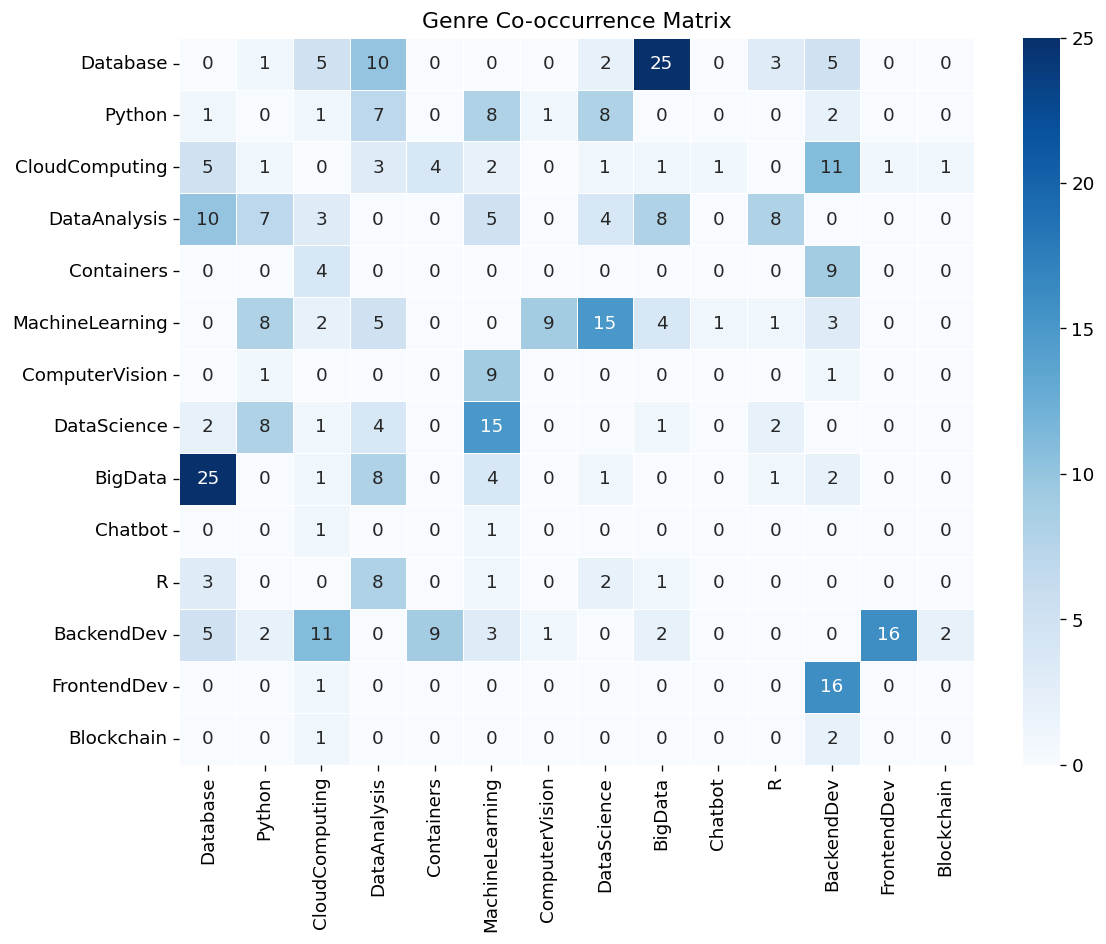

In [13]:
co = courses[genre_cols].T.dot(courses[genre_cols])
np.fill_diagonal(co.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Genre Co-occurrence Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_genre_cooccurrence_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. Overlap: Rated Courses vs Catalogue

In [14]:
rated_ids    = set(ratings['item'].unique())
catalogue_ids = set(courses['COURSE_ID'].unique())
overlap = rated_ids & catalogue_ids

print(f"Courses in ratings         : {len(rated_ids):,}")
print(f"Courses in catalogue       : {len(catalogue_ids):,}")
print(f"Overlap (both datasets)    : {len(overlap):,}")
print(f"Rated but NOT in catalogue : {len(rated_ids - catalogue_ids):,}")
print(f"Catalogue but NOT rated    : {len(catalogue_ids - rated_ids):,}")


Courses in ratings         : 126
Courses in catalogue       : 307
Overlap (both datasets)    : 126
Rated but NOT in catalogue : 0
Catalogue but NOT rated    : 181


## 11. Summary & Key Findings

In [15]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"  Total ratings         : {len(ratings):,}")
print(f"  Unique users          : {ratings['user'].nunique():,}")
print(f"  Unique rated courses  : {ratings['item'].nunique():,}")
print(f"  Rating range          : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"  Mean rating           : {ratings['rating'].mean():.3f}")
print(f"  Matrix sparsity       : {sparsity:.4%}")
print()
print(f"  Courses in catalogue  : {len(catalogue_ids)}")
print(f"  Genre tags available  : {len(genre_cols)}")
print(f"  Avg genres per course : {courses['num_genres'].mean():.2f}")


DATASET SUMMARY
  Total ratings         : 233,306
  Unique users          : 33,901
  Unique rated courses  : 126
  Rating range          : 2.0 – 3.0
  Mean rating           : 2.953
  Matrix sparsity       : 94.5381%

  Courses in catalogue  : 307
  Genre tags available  : 14
  Avg genres per course : 1.54
